In [18]:
import sys
sys.path.append('..')
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import seaborn as sns
import plotly.express as px
from pathlib import Path
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
import scipy.stats as stats

In [132]:
pyeensis_dict = dict()

pyeensis_dir  = Path(r'../data/pyeensis')
pbar = tqdm(pyeensis_dir.glob("*.csv"), total=len(list(pyeensis_dir.glob("*.csv"))))
overall_disp = []
for path in pbar:
    df = pd.read_csv(path)
    trajs = df[['track_id', 'x', 'y']]
    
    disp = trajs.groupby('track_id').diff().dropna().melt()['value']
    overall_disp.append(disp)
overall_disp_pyeensis = pd.concat(overall_disp)

100%|██████████| 45/45 [00:08<00:00,  5.20it/s]


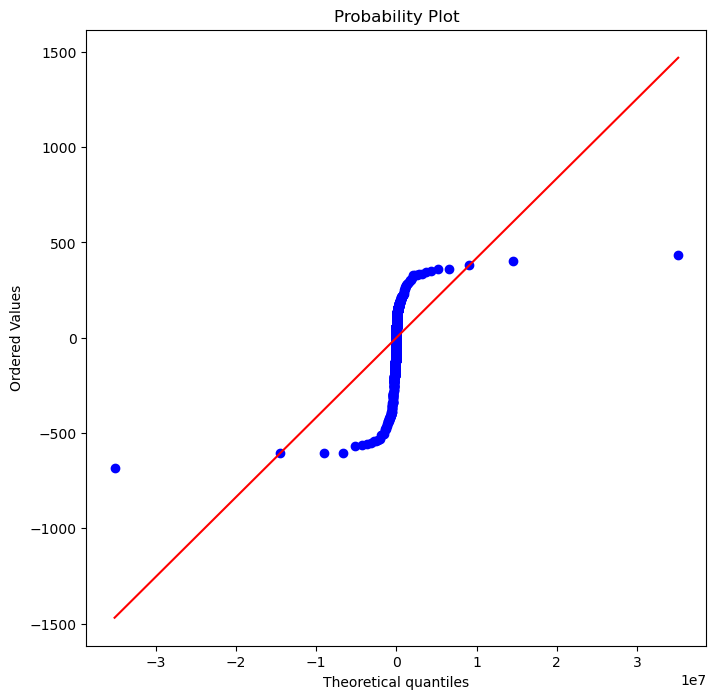

In [133]:
plt.figure(figsize=(8,8))
stats.probplot(overall_disp_pyeensis, dist=stats.cauchy, plot=plt)
plt.show()

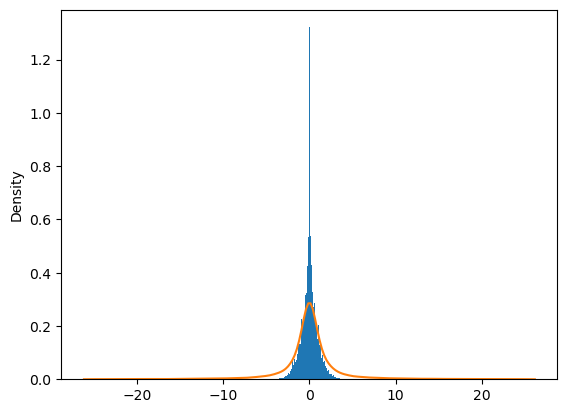

In [134]:
plt.hist(overall_disp_pyeensis, bins=500, range=(-25, 25), density=True)
cauchy = np.random.standard_cauchy(100000)
# norm = np.random.standard_normal(100000)
# student = np.random.standard_t(3, 100000)
sns.kdeplot(cauchy[np.abs(cauchy)<25])
# sns.kdeplot(student[np.abs(student)<25])
plt.show()

In [135]:
pyeensis_dict = dict()

pyeensis_dir  = Path(r'../data/knn_kalman/pyeensis')
pbar = tqdm(pyeensis_dir.glob("*.csv"), total=len(list(pyeensis_dir.glob("*.csv"))))
overall_disp = []
for path in pbar:
    df = pd.read_csv(path)
    trajs = df[['track_id', 'x', 'y']]
    disp = trajs.groupby('track_id').diff().dropna().melt()['value']
    overall_disp.append(disp)
kalman_overall_disp_pyeensis = pd.concat(overall_disp)

100%|██████████| 45/45 [00:07<00:00,  5.64it/s]


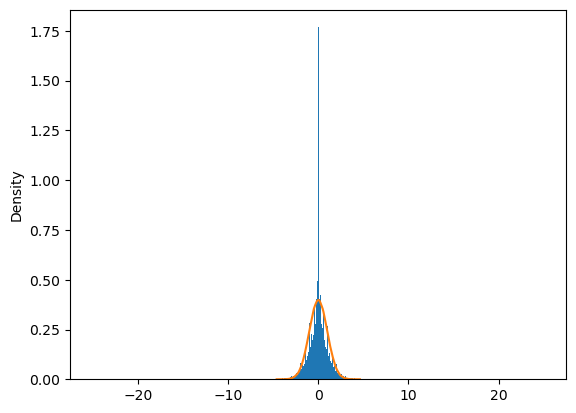

In [139]:
plt.hist(kalman_overall_disp_pyeensis, bins=500, range=(-25, 25), density=True)
cauchy = np.random.standard_cauchy(100000)
norm = np.random.standard_normal(100000)
# student = np.random.standard_t(3, 100000)
sns.kdeplot(norm[np.abs(norm)<25])
# sns.kdeplot(student[np.abs(student)<25])
plt.show()

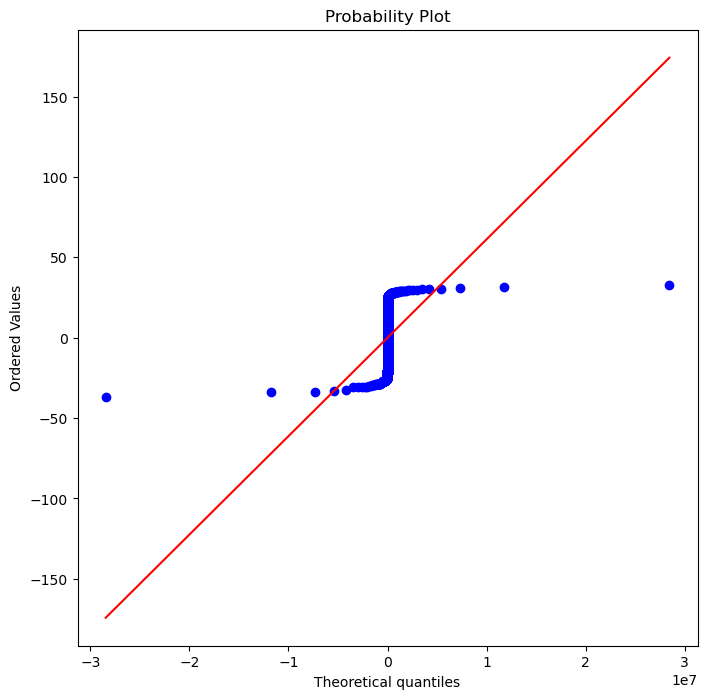

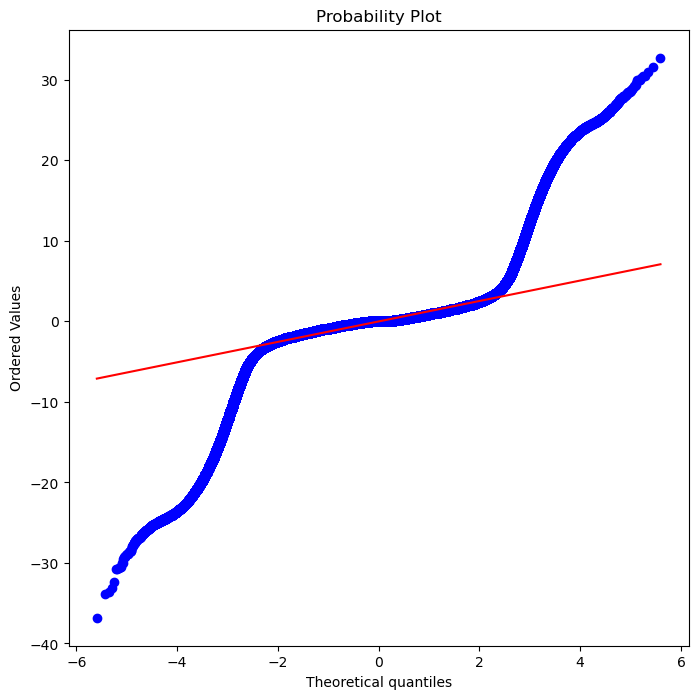

In [140]:
plt.figure(figsize=(8,8))
stats.probplot(kalman_overall_disp_pyeensis, dist=stats.cauchy, plot=plt)
plt.show()

plt.figure(figsize=(8,8))
stats.probplot(kalman_overall_disp_pyeensis, dist='norm', plot=plt)
plt.show()